In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from pathlib import Path

In [2]:
BASE_DIR = Path("Data/Raw/TCAT_Ridership_Aggregated")

In [3]:
def _read_any_table(path: Path, **read_kwargs) -> pd.DataFrame:
    suffix = path.suffix.lower()

    if suffix in [".csv", ".txt"]:
        return pd.read_csv(path, header=1, **read_kwargs)

    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path, header=1, **read_kwargs)

    raise ValueError(f"Unsupported file type: {path}")

def import_all_routes(base_dir: Path = BASE_DIR):
    """
    Returns:
      - by_hour: dict[str, DataFrame]
      - by_trip: dict[str, DataFrame]
      - by_hour_all: concatenated DataFrame
      - by_trip_all: concatenated DataFrame
    """
    by_hour = {}
    by_trip = {}

    for route_dir in sorted([p for p in base_dir.iterdir() if p.is_dir()]):
        route = route_dir.name  # e.g., "10"
        
        # --- locate files (robust to extension / small naming variations) ---
        # "10 APC by Hour" could be "10 APC by Hour.csv" or ".xlsx", etc.
        hour_candidates = list(route_dir.glob(f"{route} APC by Hour.*"))
        trip_candidates = list(route_dir.glob(f"{route} APC by Trip.*"))  # allow extension flexibility

        # If you *know* Trip is always .xlsx and want to enforce:
        # trip_candidates = list(route_dir.glob(f"{route} APC by Trip.xlsx"))

        if len(hour_candidates) == 0:
            print(f"[WARN] Missing by-hour file for route {route} in {route_dir}")
        elif len(hour_candidates) > 1:
            print(f"[WARN] Multiple by-hour files for route {route}: {[p.name for p in hour_candidates]} (using first)")
        
        if len(trip_candidates) == 0:
            print(f"[WARN] Missing by-trip file for route {route} in {route_dir}")
        elif len(trip_candidates) > 1:
            print(f"[WARN] Multiple by-trip files for route {route}: {[p.name for p in trip_candidates]} (using first)")

        # --- read if present ---
        if hour_candidates:
            df_h = _read_any_table(hour_candidates[0])
            df_h["route"] = route
            by_hour[route] = df_h

        if trip_candidates:
            df_t = _read_any_table(trip_candidates[0])
            df_t["route"] = route
            by_trip[route] = df_t

    # --- concatenate (if any) ---
    by_hour_all = pd.concat(by_hour.values(), ignore_index=True) if by_hour else pd.DataFrame()
    by_trip_all = pd.concat(by_trip.values(), ignore_index=True) if by_trip else pd.DataFrame()

    return by_hour, by_trip, by_hour_all, by_trip_all

by_hour_dict, by_trip_dict, by_hour_all, by_trip_all = import_all_routes()
print(by_hour_all.shape, by_trip_all.shape)

(408, 5) (8965, 5)


In [4]:
by_hour_all

,Hour,APC Boards,APC Alights,Difference,route
0,6,0,2,-1,10
1,7,10686,8955,0.1933,10
2,8,33680,29993,0.122929,10
3,9,43540,37562,0.15915,10
4,10,31884,35266,-0.0959,10
...,...,...,...,...,...
403,20,7607,7544,0.008351,92
404,21,7660,7126,0.074937,92
405,22,7500,7074,0.060221,92
406,23,7455,7216,0.033121,92


In [5]:
by_hour_all.dtypes

Hour              str
APC Boards     object
APC Alights    object
Difference     object
route             str
dtype: object

In [6]:
by_hour_all = by_hour_all[by_hour_all["Hour"] != "Total"].copy()

by_hour_all['APC Boards'] = pd.to_numeric(by_hour_all['APC Boards'], errors='coerce')
by_hour_all['APC Alights'] = pd.to_numeric(by_hour_all['APC Alights'], errors='coerce')
by_hour_all['Hour'] = pd.to_numeric(by_hour_all['Hour'], errors='coerce')

In [7]:
by_hour_all["APC Boards Standardized"] = (
    by_hour_all
        .groupby("route")["APC Boards"]
        .transform(lambda x: (x - x.mean()) / x.std())
)

In [8]:
# Use raw boards
rd = by_hour_all.copy()

In [ ]:
cornell_routes = [
    "10","20","30","30W","31","31W","32","37",
    "40","43","51","52",
    "81","82","90","92"
]

cornell_only = ["30","51","82"]

no_cornell = ["11","13","14","14S","15","17","21","36","65","67"]


In [10]:
rd["running"] = rd["Hour"] - 18
rd["post"] = (rd["running"] >= 0).astype(int)

rd = rd[(rd["running"] <= 2) & (rd["running"] >= -3)]

In [12]:
rd_subset = rd[
    rd["route"].isin(cornell_only + no_cornell)
].copy()

rd_subset["treated"] = rd_subset["route"].isin(cornell_only).astype(int)

model_pure = smf.ols(
    "Q('APC Boards') ~ post + running + post:running + post:treated",
    data=rd_subset
).fit(cov_type="cluster", cov_kwds={"groups": rd_subset["route"]})

print(model_pure.summary())

                            OLS Regression Results                            
Dep. Variable:        Q('APC Boards')   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                    0.7321
Date:                Tue, 03 Mar 2026   Prob (F-statistic):              0.587
Time:                        18:00:32   Log-Likelihood:                -817.36
No. Observations:                  72   AIC:                             1645.
Df Residuals:                      67   BIC:                             1656.
Df Model:                           4                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.402e+04   9061.391      1.547   

In [13]:
rd_subset = rd_subset[rd_subset["APC Boards"] > 0].copy()
rd_subset["log_boards"] = np.log(rd_subset["APC Boards"])

model_pct = smf.ols(
    "log_boards ~ post + running + post:running + post:treated",
    data=rd_subset
).fit(cov_type="cluster", cov_kwds={"groups": rd_subset["route"]})

print(model_pct.summary())

                            OLS Regression Results                            
Dep. Variable:             log_boards   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     4.325
Date:                Tue, 03 Mar 2026   Prob (F-statistic):             0.0214
Time:                        18:00:32   Log-Likelihood:                -135.12
No. Observations:                  70   AIC:                             280.2
Df Residuals:                      65   BIC:                             291.5
Df Model:                           4                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        8.7294      0.447     19.530   

In [17]:
rd_subset = rd_subset[rd_subset["APC Boards"] > 0].copy()
rd_subset["log_boards"] = np.log(rd_subset["APC Boards"])

model_pct = smf.ols(
    "log_boards ~ post + running + post:running + post:treated + C(route)",
    data=rd_subset
).fit(cov_type="cluster", cov_kwds={"groups": rd_subset["route"]})

print(model_pct.summary())

                            OLS Regression Results                            
Dep. Variable:             log_boards   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     382.8
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           1.54e-12
Time:                        18:15:41   Log-Likelihood:                -80.190
No. Observations:                  70   AIC:                             194.4
Df Residuals:                      53   BIC:                             232.6
Df Model:                          16                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          10.1556      0.433     

/Users/stevenzhou/miniconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [29]:
# Use raw boards
rd_placebo = by_hour_all.copy()

rd_placebo["running"] = rd_placebo["Hour"] - 11
rd_placebo["post"] = (rd_placebo["running"] >= 0).astype(int)

rd_placebo = rd_placebo[(rd_placebo["running"] <= 2) & (rd_placebo["running"] >= -3)]

rd_subset = rd_placebo[
    rd_placebo["route"].isin(cornell_only + no_cornell)
].copy()

rd_subset["treated"] = rd_subset["route"].isin(cornell_only).astype(int)

rd_subset = rd_subset[rd_subset["APC Boards"] > 0].copy()
rd_subset["log_boards"] = np.log(rd_subset["APC Boards"])

model_pct = smf.ols(
    "log_boards ~ post + running + post:running + post:treated + C(route)",
    data=rd_subset
).fit(cov_type="cluster", cov_kwds={"groups": rd_subset["route"]})

print(model_pct.summary())

                            OLS Regression Results                            
Dep. Variable:             log_boards   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     95.29
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           5.51e-09
Time:                        19:05:39   Log-Likelihood:                -87.472
No. Observations:                  67   AIC:                             208.9
Df Residuals:                      50   BIC:                             246.4
Df Model:                          16                                         
Covariance Type:              cluster                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           8.3556      0.577     

/Users/stevenzhou/miniconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 4
  warnings.warn('covariance of constraints does not have full '


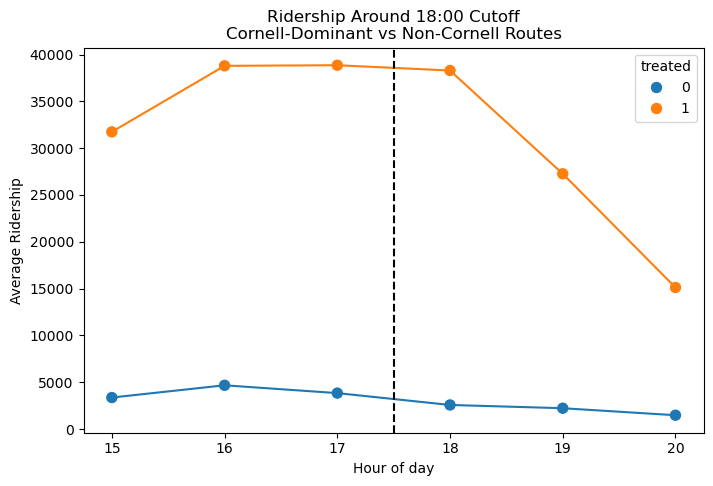

In [14]:
plot_data = rd_subset.copy()

# Aggregate mean ridership by hour and treatment group
plot_data = (
    plot_data
    .groupby(["Hour","treated"])["APC Boards"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=plot_data,
    x="Hour",
    y="APC Boards",
    hue="treated",
    s=80
)

sns.lineplot(
    data=plot_data,
    x="Hour",
    y="APC Boards",
    hue="treated",
    legend=False
)

plt.axvline(17.5, color="black", linestyle="--")

plt.xlabel("Hour of day")
plt.ylabel("Average Ridership")
plt.title("Ridership Around 18:00 Cutoff\nCornell-Dominant vs Non-Cornell Routes")

plt.show()

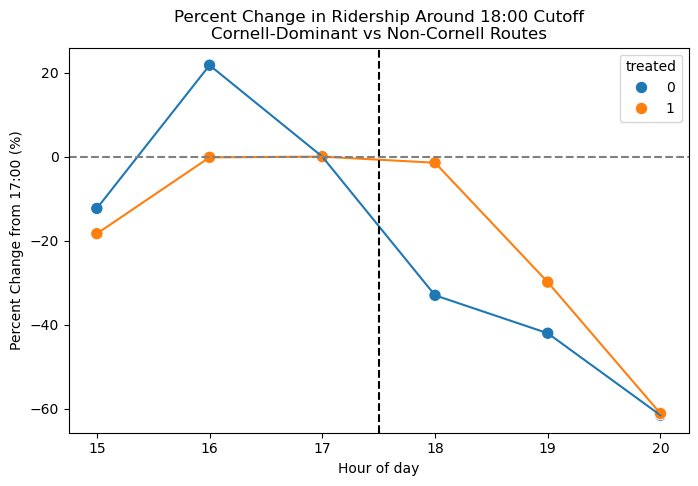

In [15]:
plot_data = rd_subset.copy()

# Aggregate mean ridership by hour and treatment group
plot_data = (
    plot_data
    .groupby(["Hour","treated"])["APC Boards"]
    .mean()
    .reset_index()
)

# Use hour 17 as baseline for each group
baseline = plot_data[plot_data["Hour"] == 17][["treated","APC Boards"]]
baseline = baseline.rename(columns={"APC Boards":"baseline"})

plot_data = plot_data.merge(baseline, on="treated")

# Percentage change relative to hour 17
plot_data["pct_change"] = (
    (plot_data["APC Boards"] - plot_data["baseline"])
    / plot_data["baseline"] * 100
)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=plot_data,
    x="Hour",
    y="pct_change",
    hue="treated",
    s=80
)

sns.lineplot(
    data=plot_data,
    x="Hour",
    y="pct_change",
    hue="treated",
    legend=False
)

plt.axvline(17.5, color="black", linestyle="--")

plt.xlabel("Hour of day")
plt.ylabel("Percent Change from 17:00 (%)")
plt.title("Percent Change in Ridership Around 18:00 Cutoff\nCornell-Dominant vs Non-Cornell Routes")

plt.axhline(0, color="gray", linestyle="--")

plt.show()

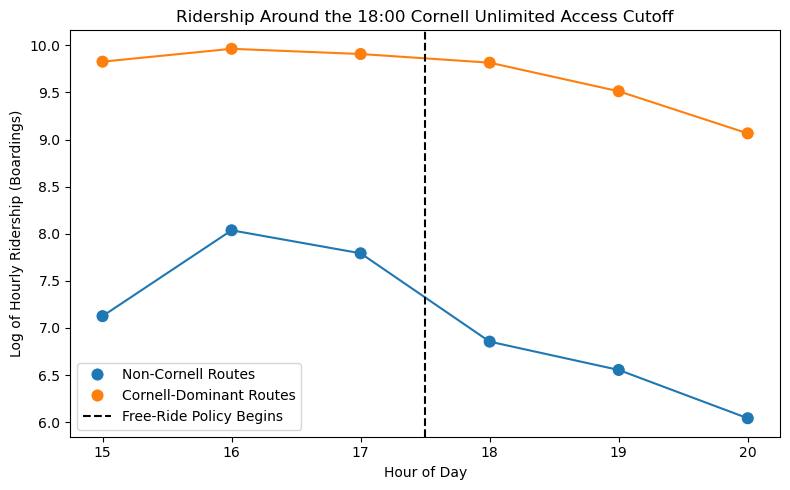

In [23]:
plot_data = rd_subset.copy()

plot_data = (
    plot_data
    .groupby(["Hour","treated"])["log_boards"]
    .mean()
    .reset_index()
)

# Map treatment labels for clarity
plot_data["group"] = plot_data["treated"].map({
    0: "Non-Cornell Routes",
    1: "Cornell-Dominant Routes"
})

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=plot_data,
    x="Hour",
    y="log_boards",
    hue="group",
    s=90
)

sns.lineplot(
    data=plot_data,
    x="Hour",
    y="log_boards",
    hue="group",
    legend=False
)

# Policy cutoff
plt.axvline(17.5, color="black", linestyle="--", label="Free-Ride Policy Begins")

plt.xlabel("Hour of Day")
plt.ylabel("Log of Hourly Ridership (Boardings)")
plt.title("Ridership Around the 18:00 Cornell Unlimited Access Cutoff")

plt.legend(title="")

plt.tight_layout()
plt.show()